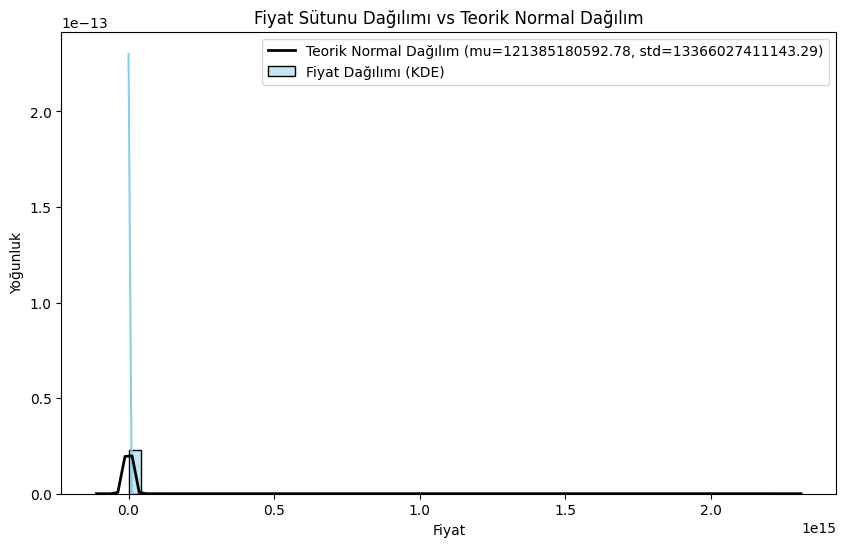

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Veriyi yükleme
file_path = '../scraping/data/train_data.csv'
df = pd.read_csv(file_path)

# Eksik verileri (NaN) görselleştirme öncesi temizleyelim ki hata vermesin
fiyat_verisi = df['fiyat'].dropna()

# 1. Grafik: Histogram ve KDE (Kernel Density Estimation)
plt.figure(figsize=(10, 6))
sns.histplot(fiyat_verisi, kde=True, stat="density", color='skyblue', bins=50, label='Fiyat Dağılımı (KDE)')

# Olası bir Normal Dağılımın Teorik Eğrisini Çizdirme (Referans için)
mu, std = norm.fit(fiyat_verisi) # Verinin ortalamasını ve standart sapmasını bul
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Teorik Normal Dağılım (mu={mu:.2f}, std={std:.2f})')

plt.title('Fiyat Sütunu Dağılımı vs Teorik Normal Dağılım')
plt.xlabel('Fiyat')
plt.ylabel('Yoğunluk')
plt.legend()
plt.show()

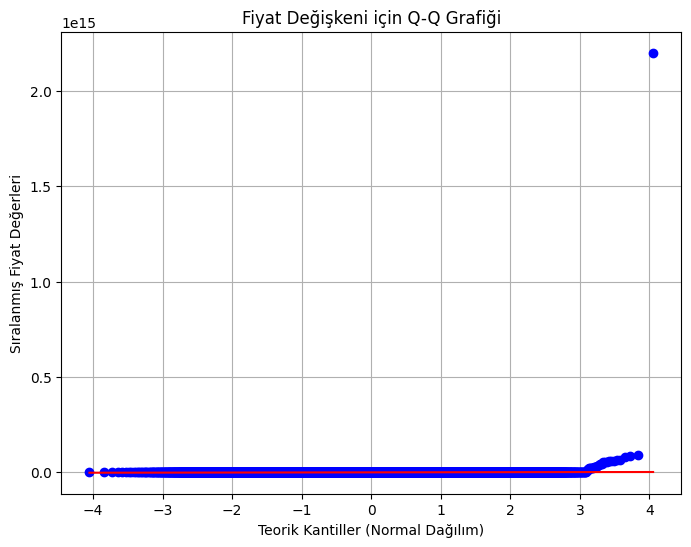

In [2]:
import scipy.stats as stats

# 2. Grafik: Q-Q Plot
plt.figure(figsize=(8, 6))
stats.probplot(fiyat_verisi, dist="norm", plot=plt)

plt.title('Fiyat Değişkeni için Q-Q Grafiği')
plt.xlabel('Teorik Kantiller (Normal Dağılım)')
plt.ylabel('Sıralanmış Fiyat Değerleri')
plt.grid(True)
plt.show()

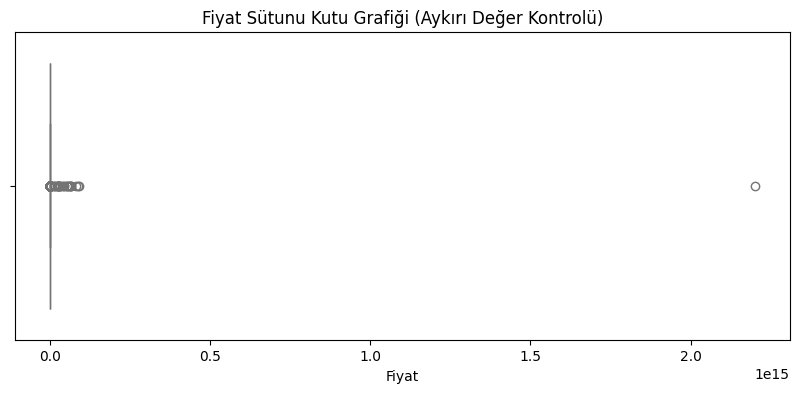

In [3]:
# 3. Grafik: Boxplot (Kutu Grafiği)
plt.figure(figsize=(10, 4))
sns.boxplot(x=fiyat_verisi, color='lightgreen')

plt.title('Fiyat Sütunu Kutu Grafiği (Aykırı Değer Kontrolü)')
plt.xlabel('Fiyat')
plt.show()

In [4]:
from scipy.stats import shapiro, skew, kurtosis

# Çarpıklık (Skewness) ve Basıklık (Kurtosis) 
# Skewness 0'a, Kurtosis 3'e (veya Fisher tanımıyla 0'a) yakınsa normal dağılımdır.
print(f"Çarpıklık (Skewness): {skew(fiyat_verisi):.4f}")
print(f"Basıklık (Kurtosis): {kurtosis(fiyat_verisi):.4f}\n")

# Shapiro-Wilk Testi
# Not: 5000'den büyük sample'lar için Shapiro-Wilk çok hassastır.
stat, p_value = shapiro(fiyat_verisi)
print(f'Shapiro-Wilk Test İstatistiği: {stat:.4f}, p-değeri: {p_value:.4f}')

if p_value > 0.05:
    print("Sonuç: Fiyat verisi Normal Dağılıma UYMAKTADIR (H0 reddedilemez).")
else:
    print("Sonuç: Fiyat verisi Normal Dağılıma UYMAMAKTADIR (H0 reddedilir).")

Çarpıklık (Skewness): 162.5433
Basıklık (Kurtosis): 26739.7833

Shapiro-Wilk Test İstatistiği: 0.0013, p-değeri: 0.0000
Sonuç: Fiyat verisi Normal Dağılıma UYMAMAKTADIR (H0 reddedilir).


c:\Users\Baran\anaconda3\envs\sp500\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 27440.
  res = hypotest_fun_out(*samples, **kwds)
